# Imports

In [1]:
from src.data_utils import *
from src.next_token_dataset import *
from src.lstm_model import LSTMClasssifier
from src.lstm_train import train_model as train_lstm_model
from src.plot_utils import *
from src.eval_lstm import print_example_generation_lstm
from src.eval_transformer_pipeline import evaluate_transformer, print_example_generation_transformer

from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import evaluate

from transformers import AutoTokenizer, AutoModelForCausalLM

from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace
from transformers import PreTrainedTokenizerFast


d:\Programming\VSCodeProjects\Yandex ML DL\Sprint_2\text-autocomplete\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# MOVE TO CONFIG

In [3]:
DATASET_URL = "https://code.s3.yandex.net/deep-learning/tweets.txt"

DATA_PATH = Path("data")
DATA_PATH.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = DATA_PATH/"raw_dataset.csv"
DS_PROC_PATH = DATA_PATH/"dataset_processed.csv"
DS_TRAIN_PATH = DATA_PATH/"train.pt"
DS_TEST_PATH = DATA_PATH/"test.pt"
DS_VAL_PATH = DATA_PATH/"val.pt"

MODELS_PATH = Path("models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Models path
PROJECT_ROOT = Path(".")
LSTM_DIR = MODELS_PATH / "lstm"
LSTM_DIR.mkdir(parents=True, exist_ok=True)

LSTM_PATH = LSTM_DIR / "lstm_model_final.pt"
LSTM_HISTORY_PATH = LSTM_DIR / "training_history.csv"
LSTM_PLOTS_DIR = LSTM_DIR / "plots"
LSTM_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LSTM_PLOT_PATH = LSTM_PLOTS_DIR / "training_curves.png"

MODEL_NAME = "distilgpt2" # наименование предобученной модели

MIN_LENGHT = 8 # минимальная длина твитта в словах

# Model params
HIDDEN_DIM = 256
EMBEDDING_DIM = HIDDEN_DIM
NUM_LAYERS = 2
DROPOUT = 0.2
VOCAB_SIZE=20000

# Training params
BATCH_SIZE = 128
NUM_EPOCHS = 1
PATIENCE_ES=NUM_EPOCHS # Early stopping
PATIENCE_SCHEDULER=2
LEARNING_RATE=3e-4
BETAS=(0.9, 0.999)
EPS=1e-8
WEIGHT_DECAY=0


RANDOM_STATE = 42

# Этап 1. Сбор и поготовка данных

## Загрузка данных

In [4]:
load_raw_data(url=DATASET_URL, save_path=RAW_DATA_PATH)

Файл уже существует: data\raw_dataset.csv


In [5]:
df_raw = pd.read_csv(RAW_DATA_PATH)
print("shape:", df_raw.shape)
df_raw.head()

shape: (698162, 1)


,tweet_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,@Kenichan I dived many times for the ball. Man...
2,"@nationwideclass no, it's not behaving at all...."
3,@Kwesidei not the whole crew \nNeed a hug
4,@LOLTrish hey long time no see! Yes.. Rains a...


## Предобработка данных

In [6]:
df_proc = df_raw.copy()
df_proc["tweet_text"] = df_proc["tweet_text"].apply(lambda x: clean_text(x, min_lenght=MIN_LENGHT))
df_proc = df_proc[df_proc['tweet_text'] != ""].reset_index(drop=True)

print(df_proc.shape)
df_proc.head()

(603194, 1)


,tweet_text
0,awww that s a bummer you shoulda got david car...
1,i dived many times for the ball managed to sav...
2,no it s not behaving at all i m mad why am i h...
3,hey long time no see yes rains a bit only a bi...
4,que me muera spring break in plain city it s s...


In [7]:
df_train, df_temp = train_test_split(df_proc, train_size=0.8, random_state=RANDOM_STATE)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=RANDOM_STATE
)

print(f"Train size: {len(df_train)}")
print(f"Val size:   {len(df_val)}")
print(f"Test size:  {len(df_test)}")

Train size: 482555
Val size:   60319
Test size:  60320



Статистика по количеству слов в тексте:
Среднее:  34
Медиана:  25
5-й перцентиль:  9
95-й перцентиль:  87


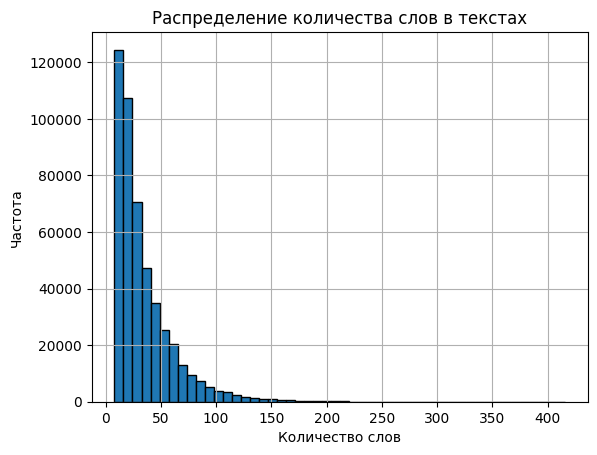

In [8]:
# смотрим статистики твитов для определения параметров
word_counts = torch.tensor([len(seq.split()) for seq in df_train['tweet_text'].values], dtype=torch.float)

print("\nСтатистика по количеству слов в тексте:")
print("Среднее: ", int(word_counts.mean())) 
print("Медиана: ", int(word_counts.median())) 
print("5-й перцентиль: ", int(word_counts.quantile(0.05)))
print("95-й перцентиль: ", int(word_counts.quantile(0.95))) 

# Гистограмма распределения длины
plt.hist(word_counts, bins=50, edgecolor='black')
plt.title("Распределение количества слов в текстах")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

In [9]:
# обучение токенизатора
tokenizer = Tokenizer(WordLevel(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

trainer = WordLevelTrainer(
    vocab_size=VOCAB_SIZE, 
    special_tokens = ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)

tokenizer.train_from_iterator(df_train["tweet_text"].astype(str), trainer)

tokenizer_lstm = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    unk_token="[UNK]",
    pad_token="[PAD]",
    bos_token="[BOS]",
    eos_token="[EOS]" 
)

In [10]:
df_train = df_train.head(1024)
df_test = df_test.head(512)
df_val = df_val.head(512)

In [11]:
if DS_TRAIN_PATH.exists() and DS_TEST_PATH.exists() and DS_VAL_PATH.exists():
    print("загрузка данных...")
    train_encodings = torch.load(DS_TRAIN_PATH, weights_only=False)
    test_encodings = torch.load(DS_TEST_PATH, weights_only=False)
    val_encodings = torch.load(DS_VAL_PATH, weights_only=False)
    print('данные загружены')
else:
    print("обработка данных...")
    train_encodings = tokenize_function(df_train["tweet_text"], tokenizer=tokenizer_lstm)
    test_encodings = tokenize_function(df_test["tweet_text"], tokenizer=tokenizer_lstm)
    val_encodings = tokenize_function(df_val["tweet_text"], tokenizer=tokenizer_lstm)

    # torch.save(train_encodings, DS_TRAIN_PATH)
    # torch.save(test_encodings, DS_TEST_PATH)
    # torch.save(val_encodings, DS_VAL_PATH)

    print("данные сохранены")

print("train_encodings:", train_encodings['input_ids'].shape)
print("train_encodings:", test_encodings['input_ids'].shape)
print("train_encodings:", val_encodings['input_ids'].shape)

обработка данных...
данные сохранены
train_encodings: torch.Size([1024, 128])
train_encodings: torch.Size([512, 128])
train_encodings: torch.Size([512, 128])


In [12]:
train_encodings["input_ids"][0]

tensor([  74,  114,  151,   16,  374,   10,   40,   19,  100,   29,    7,  639,
          24,  852,   42,  114,  411, 4846,   22, 1228,    6,  644,   16,    8,
        6789,  156,   37,   19,   54,   18,    6,  444,  137, 3694,    7, 2257,
          80,  737, 5285,   45,  151,   89,   77,    4,  120,   10,  123,  419,
         549,   14,  772,   50,  124,   69, 2640,  276,   14,    6,  721,  157,
         154,   68,   10, 1997,  127,  137,   22,    5, 3464,  294, 1689,  982,
          38,  220,  111, 6203,  191,   11,   37, 2007,   45,  196,    7,  253,
        1674,  515,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

## Формирование датасета

In [13]:
train_dataset = TweetDataset(train_encodings, tokenizer=tokenizer_lstm)
test_dataset = TweetDataset(test_encodings, tokenizer=tokenizer_lstm)
val_dataset = TweetDataset(val_encodings, tokenizer=tokenizer_lstm)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print(f'train_dataset: {len(train_dataset)}, '
      f'test_dataset: {len(test_dataset)}, ' 
      f'val_dataset: {len(val_dataset)}')

print(f'train_dataloader: {len(train_dataloader)}, '
      f'test_dataloader: {len(test_dataloader)}, ' 
      f'val_dataloader: {len(val_dataloader)}')

train_dataset: 1024, test_dataset: 512, val_dataset: 512
train_dataloader: 8, test_dataloader: 4, val_dataloader: 4


# Этап 2. Реализация рекуррентой сети

In [14]:
model_lstm = LSTMClasssifier(vocab_size=VOCAB_SIZE,
                             embedding_dim=EMBEDDING_DIM,
                             hidden_dim=HIDDEN_DIM,
                             n_layers=NUM_LAYERS,
                             dropout=DROPOUT).to(device)

param_count = sum(p.numel() for p in model_lstm.parameters())
print(f"param_count: {param_count:,}")

param_count: 11,312,672


# Этап 3. Тренировка модели

## Обучение

In [15]:
optimizer = torch.optim.Adam(
    model_lstm.parameters(),
    lr=3e-4,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',      
    factor=0.5,      
    patience=PATIENCE_SCHEDULER,       
    verbose=True
)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

d:\Programming\VSCodeProjects\Yandex ML DL\Sprint_2\text-autocomplete\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [16]:
history_df = train_lstm_model(
    model=model_lstm,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=NUM_EPOCHS,
    tokenizer=tokenizer_lstm,
    device=device,
    save_path=LSTM_PATH,
    history_path=LSTM_HISTORY_PATH,
    patience=PATIENCE_ES,
    scheduler=scheduler
)

Начало обучения | Epochs: 1 | Patience: 1 | Device: cuda



[Evaluating]: 100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Epoch 1 | LR: 0.000300 | Train Loss: 9.9003 | Val Loss: 9.8944 | Rouge1: 3.65% | Rouge2: 0.01% | RougeL: 3.28%


Обучение завершено!
Восстановлена модель с лучшим RougeL
История: models\lstm\training_history.csv
Лучшая модель: эпоха 1
Rouge:
val_loss: 9.8944
rouge1: 0.0365
rouge2: 0.0001
rougeL: 0.0328


График сохранён: models\lstm\plots\training_curves.png


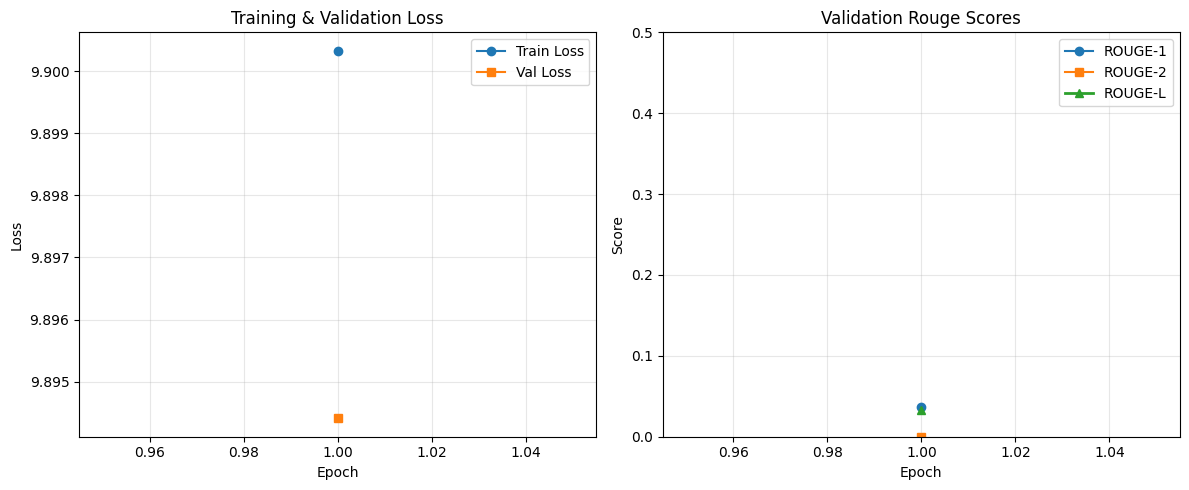

In [17]:
# строим графики
plot_training_history(history_df, save_path=LSTM_PLOT_PATH)

## Тестирование

In [18]:
print_example_generation_lstm(
    model=model_lstm, 
    loader=val_dataloader, 
    tokenizer=tokenizer_lstm, 
    device=device, 
    n_examples=5)


Примеры генерации LSTM (N=5)

Example 1:
Prefix:    yeah thanks that quot someone quot should be their dad but he was too busy having fun
Predicted: hate 2 do hate we help
Target:    this weekend to help out
--------------------------------------------------

Example 2:
Prefix:    that one was just sent to twitter peeps heck guess i was at a loss for words quot king of wishful thinking
Predicted: can can be 8 now brother they good
Target:    quot new found glory l0ve the tune
--------------------------------------------------

Example 3:
Prefix:    wow so nice to have dinner with friends thanks for meeting up bp just awesome time to go honey
Predicted: see hate w i new can send
Target:    i will bring u to home
--------------------------------------------------

Example 4:
Prefix:    thank you for sending them to me x i m out awesome i love how i can drink with
Predicted: n today a what see going tonight
Target:    dan s family without them minding
------------------------------------

# Этап 4. Использование предобученного трансформера

In [ ]:
tokenizer_gpt = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer_gpt.pad_token = tokenizer_gpt.eos_token
model_gpt = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)

model_gpt.config.pad_token_id = tokenizer_gpt.pad_token_id
model_gpt.generation_config.pad_token_id = tokenizer_gpt.pad_token_id

In [30]:
df_val.head()

,tweet_text
152672,yeah thanks that quot someone quot should be t...
547738,that one was just sent to twitter peeps heck g...
316579,wow so nice to have dinner with friends thanks...
384675,thank you for sending them to me x i m out awe...
303117,haha ty new shout out video next week


In [35]:
val_encodings_gpt = tokenize_function(df_val["tweet_text"], tokenizer=tokenizer_gpt)
val_dataset_gpt = GPTTweetDataset(val_encodings_gpt)
val_dataloader_gpt = DataLoader(val_dataset_gpt, batch_size=BATCH_SIZE)

print(f'val_dataset: {len(val_dataset_gpt)}')
print(f'val_dataloader: {len(val_dataloader_gpt)}')

val_dataset: 512
val_dataloader: 4


In [32]:
evaluate_transformer(model=model_gpt,
                     tokenizer=tokenizer_gpt,
                     loader=val_dataloader_gpt,
                     device=device)

[Evaluating]: 100%|██████████| 4/4 [00:25<00:00,  6.32s/it]


{'rouge1': np.float64(0.0766158757414783),
 'rouge2': np.float64(0.008219283086607824),
 'rougeL': np.float64(0.07411809790583562)}

In [36]:
print_example_generation_lstm(
    model=model_gpt, 
    loader=val_dataloader_gpt, 
    tokenizer=tokenizer_gpt, 
    device=device, 
    n_examples=5)


Примеры генерации LSTM (N=5)

Example 1:
Prefix:    yeah thanks that quot someone quot should be their dad but he was too busy having
Predicted: to deal with the fact that
Target:    fun this weekend to help out
--------------------------------------------------

Example 2:
Prefix:    that one was just sent to twitter peeps heck guess i was at a loss for words quot king of wishful thinking
Predicted: .
Target:    quot new found glory l0ve the tune
--------------------------------------------------

Example 3:
Prefix:    wow so nice to have dinner with friends thanks for meeting up bp just awesome time to go
Predicted: to the party.
Target:    honey i will bring u to home
--------------------------------------------------

Example 4:
Prefix:    thank you for sending them to me x i m out awesome i love how i can drink with
Predicted: my friends and family. i love
Target:    dan s family without them minding
--------------------------------------------------

Example 5:
Prefix:    haha t